# Teaching traffic baselines vs graph Koopman (METR-LA slice)

This notebook compares a small `GraphKoopmanModel` against the in-repo teaching
spatiotemporal GNN forecasters on **one documented METR-LA weekday cache slice**
(or a seeded synthetic sensor-ring fallback). Every traffic model uses the same
chronological train / validation / test ratios (`0.7` / `0.1` / `0.2`), lookback,
evaluation horizons, and mean absolute error (MAE) reporting.

**Objective.** Show how to run protocol-matched teaching comparisons, print each
baseline's `ForecasterProtocol.deviations` next to the numbers, and keep mesh-
weather GraphCast clearly separated from sensor-traffic results.

**Prerequisites.** An installed `koopman_graph` environment. Continuous-
integration notebook smoke (`nbmake`) sets a short `IS_TEST` path. Optional
`[baselines-ode]` enables STGODE; without it that row is skipped.

> **Honesty.** These are **teaching** baselines, not LibCity / BasicTS
> leaderboard reproductions. Do not read the MAE table as METR-LA state of the
> art. GraphCast appears only on a tiny lat–lon mesh and is **not** comparable
> to PEMS/METR sensor-graph scores.

## Setup

In [1]:
import os
import warnings

from tqdm.std import TqdmExperimentalWarning, TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data

import koopman_graph
from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.baselines.gnn import (
    AGCRNBaseline,
    DCRNNBaseline,
    GraphCastBaseline,
    GraphWaveNetBaseline,
    MTGNNBaseline,
    STGCNBaseline,
    TEACHING_BASELINES,
)
from koopman_graph.baselines.gnn.graphcast import build_teaching_mesh_edge_index
from koopman_graph.data import GraphSnapshotSequence
from koopman_graph.metrics import evaluate_forecast

IS_TEST = bool(
    os.environ.get("NBMAKE")
    or os.environ.get("CI")
    or os.environ.get("IS_TEST")
)

SEED = 0
HISTORY_LEN = 4
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.7, 0.1, 0.2
HORIZONS = (1, 3) if IS_TEST else (3, 6, 12)
NUM_NODES = 12 if IS_TEST else 24
NUM_TIMESTEPS = 48 if IS_TEST else 96
EPOCHS = 2 if IS_TEST else 20
LR = 5e-3
LATENT_DIM = 8
HIDDEN = 16 if IS_TEST else 32

torch.manual_seed(SEED)
print(f"koopman_graph {koopman_graph.__version__}")
print(
    f"IS_TEST={IS_TEST}  N={NUM_NODES}  T={NUM_TIMESTEPS}  "
    f"history_len={HISTORY_LEN}  horizons={HORIZONS}  epochs={EPOCHS}"
)
print(f"registered teaching baselines: {len(TEACHING_BASELINES)}")

koopman_graph 0.11.0
IS_TEST=False  N=24  T=96  history_len=4  horizons=(3, 6, 12)  epochs=20
registered teaching baselines: 7


### Traffic slice (prefix of tutorial cache)

Prefer the shipped METR-LA weekday tutorial cache (`data/metr_la/traffic.pt`):
207 sensors, 288 five-minute steps, Gaussian-kernel road adjacency from the
DCRNN release. For a fast teaching comparison we keep sensors
**sensors** $0,\ldots,N-1$ **in cache order** (a **prefix sensor slice**, not a
geographically chosen community), truncate time, and apply the protocol
chronological split. Induced edges are those with both endpoints in the kept
prefix. If the cache is missing, fall back to a seeded diffusion process on a
ring graph with the same $N$ and $T$ — still not a leaderboard claim.

In [2]:
def induce_prefix_subgraph(
    sequence: GraphSnapshotSequence,
    *,
    num_nodes: int,
    num_timesteps: int,
) -> GraphSnapshotSequence:
    """Keep nodes ``0 .. num_nodes-1`` (cache order) and the first frames."""
    edge_index = sequence.edge_index
    keep = (edge_index[0] < num_nodes) & (edge_index[1] < num_nodes)
    sub_edges = edge_index[:, keep].contiguous()
    edge_weight = sequence[0].get("edge_weight")
    sub_weight = None if edge_weight is None else edge_weight[keep].contiguous()
    snapshots: list[Data] = []
    t_max = min(num_timesteps, sequence.num_timesteps)
    for t in range(t_max):
        data = Data(x=sequence[t].x[:num_nodes].clone(), edge_index=sub_edges)
        if sub_weight is not None:
            data.edge_weight = sub_weight.clone()
        snapshots.append(data)
    return GraphSnapshotSequence(snapshots)


def synthetic_ring_sequence(
    *,
    num_nodes: int,
    num_timesteps: int,
    seed: int,
) -> GraphSnapshotSequence:
    """Seeded ring diffusion used when the METR-LA cache is unavailable."""
    generator = torch.Generator().manual_seed(seed)
    sources = torch.arange(num_nodes)
    targets = (sources + 1) % num_nodes
    forward = torch.stack([sources, targets], dim=0)
    edge_index = torch.cat([forward, forward.flip(0)], dim=1)
    state = torch.randn(num_nodes, 1, generator=generator)
    adjacency = torch.zeros(num_nodes, num_nodes)
    adjacency[edge_index[0], edge_index[1]] = 1.0
    degree = adjacency.sum(dim=1).clamp_min(1.0)
    normalized = adjacency / degree.unsqueeze(1)
    snapshots: list[Data] = []
    for _ in range(num_timesteps):
        snapshots.append(Data(x=state.clone(), edge_index=edge_index))
        state = 0.85 * state + 0.15 * (normalized @ state)
    return GraphSnapshotSequence(snapshots)


def chronological_splits(
    sequence: GraphSnapshotSequence,
    *,
    train_ratio: float,
    val_ratio: float,
    test_ratio: float,
    history_len: int = HISTORY_LEN,
) -> tuple[GraphSnapshotSequence, GraphSnapshotSequence, GraphSnapshotSequence]:
    """Slice a sequence into contiguous train / val / test windows."""
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6
    n = sequence.num_timesteps
    n_train = max(int(n * train_ratio), history_len + 2)
    n_val = max(int(n * val_ratio), history_len + 2)
    n_test = n - n_train - n_val
    if n_test < history_len + max(HORIZONS) + 1:
        n_test = history_len + max(HORIZONS) + 1
        n_train = max(history_len + 2, n - n_val - n_test)
    train = sequence.slice(0, n_train)
    val = sequence.slice(n_train, n_train + n_val)
    test = sequence.slice(n_train + n_val, n_train + n_val + n_test)
    return train, val, test


DATA_SOURCE = "synthetic-ring-fallback"
try:
    from koopman_graph.datasets import MetrLaTrafficBenchmark

    full = MetrLaTrafficBenchmark.load_sequence()
    sequence = induce_prefix_subgraph(
        full, num_nodes=NUM_NODES, num_timesteps=NUM_TIMESTEPS
    )
    DATA_SOURCE = (
        "METR-LA tutorial cache (data/metr_la/traffic.pt); "
        f"prefix sensors 0..{NUM_NODES - 1}, T={sequence.num_timesteps}"
    )
except Exception as exc:  # noqa: BLE001 - teaching fallback must stay available
    print(f"METR-LA load unavailable ({exc!r}); using synthetic ring.")
    sequence = synthetic_ring_sequence(
        num_nodes=NUM_NODES, num_timesteps=NUM_TIMESTEPS, seed=SEED
    )

train_seq, val_seq, test_seq = chronological_splits(
    sequence,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
)
print("data:", DATA_SOURCE)
print(
    f"split lengths train/val/test = "
    f"{train_seq.num_timesteps}/{val_seq.num_timesteps}/{test_seq.num_timesteps}"
)
print(f"edges in teaching slice: {sequence.edge_index.shape[1]}")

data: METR-LA tutorial cache (data/metr_la/traffic.pt); prefix sensors 0..23, T=96
split lengths train/val/test = 67/9/20
edges in teaching slice: 82


## Motivation and background

Published traffic GNN papers and LibCity-style scripts typically couple a
specific preprocessing stack, chronological split, multi-horizon loss, and
learning-rate schedule to a large sensor graph (for example METR-LA). The
KoopmanGraph teaching ports keep the same `fit` / `predict` surface as
`GraphKoopmanModel` but document deliberate deviations in
`ForecasterProtocol` — including next-frame mean squared error (MSE) training
versus MAE evaluation claims.

Primary references for the teaching ports (verify against the module
docstrings; this notebook does not invent additional protocol details):

- Yu et al., STGCN (IJCAI 2018)
- Li et al., DCRNN (ICLR 2018)
- Wu et al., Graph WaveNet (IJCAI 2019)
- Bai et al., AGCRN (NeurIPS 2020)
- Wu et al., MTGNN (KDD 2020)
- Fang et al., STGODE (KDD 2021)
- Lam et al., GraphCast (Science 2023) — mesh-weather problem class only

## Minimal example — one protocol printout

Before fitting, inspect a single teaching protocol so the caveats sit beside
later scores.

In [3]:
demo = STGCNBaseline(
    1, HIDDEN, 1, history_len=HISTORY_LEN, num_st_blocks=1, kernel_size=2
)
proto = demo.protocol()
print(f"name={proto.name}  history_len={proto.history_len}  "
      f"horizon={proto.horizon}  metric={proto.metric}")
print(
    f"splits train/val/test = "
    f"{proto.train_ratio}/{proto.val_ratio}/{proto.test_ratio}"
)
print("deviations:")
for item in proto.deviations:
    print(f"  - {item}")

name=stgcn  history_len=4  horizon=12  metric=mae
splits train/val/test = 0.7/0.1/0.2
deviations:
  - architecture: teaching-scale ST-Conv block count and channel widths; not Yu et al. METR-LA / PEMS-BAY capacity
  - architecture: no multi-horizon direct or scheduled decoding at the claimed evaluation horizon (next-frame fit only)
  - preprocessing: no LibCity / BasicTS Z-score or sensor normalization and no dataset-specific adjacency construction pipeline; callers supply GraphSnapshotSequence features and topology
  - splits: protocol reports train/val/test = 0.7/0.1/0.2 for teaching comparisons, but fit() does not slice the sequence — callers must apply splits themselves
  - schedule: Adam with a constant learning rate (default lr=1e-3) for a caller-chosen epoch count (default 40); no paper LR schedule, warmup, or early stopping
  - loss: fit minimizes next-frame MSE on sliding windows; protocol.metric 'mae' and horizon=12 are evaluation claims, not the training objective or multi-ho

## Progressive deep dive — fit traffic models on identical splits

We train `GraphKoopmanModel` and the sensor-graph teaching baselines on
`train_seq` only, then evaluate autoregressive MAE on `test_seq` at the shared
horizons. Validation is reserved for notebook readers who want early stopping;
this smoke path does not tune on it.

In [4]:
def fit_koopman(train: GraphSnapshotSequence) -> GraphKoopmanModel:
    model = GraphKoopmanModel(
        GNNEncoder(1, HIDDEN, LATENT_DIM, num_layers=2),
        GNNDecoder(LATENT_DIM, HIDDEN, 1, num_layers=2),
        latent_dim=LATENT_DIM,
        time_step=1.0,
    )
    model.fit(train, epochs=EPOCHS, lr=LR)
    return model


def mae_at_horizons(model, test: GraphSnapshotSequence) -> dict[int, float]:
    result = evaluate_forecast(model, test, horizons=HORIZONS)
    return {hm.horizon: hm.mae for hm in result.horizons}


traffic_rows: list[dict[str, object]] = []

In [5]:
koopman = fit_koopman(train_seq)
koopman_maes = mae_at_horizons(koopman, test_seq)
traffic_rows.append(
    {
        "name": "graph_koopman",
        "model": koopman,
        "maes": koopman_maes,
        "deviations": (
            "linear latent Koopman operator with GNN encode/decode; not a "
            "LibCity traffic GNN",
            "fit uses the library training loop (not next-frame MSE of the "
            "GNN teaching baselines)",
        ),
    }
)
print("graph_koopman MAE:", koopman_maes)

graph_koopman MAE: {3: 0.3558928072452545, 6: 0.35966619849205017, 12: 0.3775358200073242}


In [6]:
baseline_ctors: list[tuple[str, object]] = [
    (
        "stgcn",
        lambda: STGCNBaseline(
            1, HIDDEN, 1, history_len=HISTORY_LEN, num_st_blocks=1, kernel_size=2
        ),
    ),
    (
        "dcrnn",
        lambda: DCRNNBaseline(
            1, HIDDEN, 1, history_len=HISTORY_LEN, diffusion_steps=1
        ),
    ),
    (
        "graph_wavenet",
        lambda: GraphWaveNetBaseline(
            1,
            HIDDEN,
            1,
            history_len=HISTORY_LEN,
            num_layers=2,
            adaptive_adj=True,
            num_nodes=train_seq.num_nodes,
        ),
    ),
    (
        "agcrn",
        lambda: AGCRNBaseline(
            1,
            HIDDEN,
            1,
            history_len=HISTORY_LEN,
            embed_dim=8,
            num_nodes=train_seq.num_nodes,
        ),
    ),
    (
        "mtgnn",
        lambda: MTGNNBaseline(
            1,
            HIDDEN,
            1,
            history_len=HISTORY_LEN,
            num_layers=2,
            embed_dim=8,
            num_nodes=train_seq.num_nodes,
        ),
    ),
]

# STGODE only when torchdiffeq is importable.
try:
    import torchdiffeq  # noqa: F401

    from koopman_graph.baselines.gnn import STGODEBaseline as _STGODE

    baseline_ctors.append(
        (
            "stgode",
            lambda: _STGODE(1, HIDDEN, 1, history_len=HISTORY_LEN, num_layers=1),
        )
    )
except ImportError:
    print("STGODE skipped (install koopman-graph[baselines-ode] to enable).")

In [7]:
for name, ctor in baseline_ctors:
    model = ctor()
    protocol = model.protocol()
    model.fit(train_seq, epochs=EPOCHS, lr=LR)
    maes = mae_at_horizons(model, test_seq)
    traffic_rows.append(
        {
            "name": protocol.name,
            "model": model,
            "maes": maes,
            "deviations": protocol.deviations,
        }
    )
    print(f"{protocol.name} MAE:", maes)

stgcn MAE: {3: 0.34886422753334045, 6: 0.4545038044452667, 12: 0.5264254212379456}
dcrnn MAE: {3: 0.2955324351787567, 6: 0.3866461217403412, 12: 0.4742565155029297}
graph_wavenet MAE: {3: 0.34405574202537537, 6: 0.4436403810977936, 12: 0.6354072690010071}
agcrn MAE: {3: 0.5145336985588074, 6: 0.5936002731323242, 12: 0.6263357400894165}
mtgnn MAE: {3: 0.24444808065891266, 6: 0.3822220265865326, 12: 0.5525135397911072}
stgode MAE: {3: 0.1887725591659546, 6: 0.2812834680080414, 12: 0.368239164352417}


## Progressive deep dive — GraphCast mesh (separate problem class)

Lam et al. GraphCast targets **global mesh weather**, not loop-detector traffic
graphs. The teaching adapter runs on `build_teaching_mesh_edge_index` only. We
fit it here on a tiny lat–lon mesh and report MAE in a **separate Results
block** — never in the traffic bar chart.

In [8]:
def mesh_diffusion_sequence(
    *,
    num_lat: int = 3,
    num_lon: int = 4,
    timesteps: int = 40,
    seed: int = 1,
) -> GraphSnapshotSequence:
    generator = torch.Generator().manual_seed(seed)
    edge_index = build_teaching_mesh_edge_index(num_lat=num_lat, num_lon=num_lon)
    num_nodes = num_lat * num_lon
    state = torch.randn(num_nodes, 1, generator=generator)
    adjacency = torch.zeros(num_nodes, num_nodes)
    adjacency[edge_index[0], edge_index[1]] = 1.0
    degree = adjacency.sum(dim=1).clamp_min(1.0)
    normalized = adjacency / degree.unsqueeze(1)
    snapshots: list[Data] = []
    for _ in range(timesteps):
        snapshots.append(Data(x=state.clone(), edge_index=edge_index))
        state = 0.85 * state + 0.15 * (normalized @ state)
    return GraphSnapshotSequence(snapshots)


HISTORY_LEN_MESH = 2
mesh_seq = mesh_diffusion_sequence(timesteps=36 if IS_TEST else 48, seed=SEED + 1)
mesh_train, _mesh_val, mesh_test = chronological_splits(
    mesh_seq,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    history_len=HISTORY_LEN_MESH,
)
graphcast = GraphCastBaseline(
    1, HIDDEN, 1, history_len=HISTORY_LEN_MESH, num_processor_layers=2
)
gc_protocol = graphcast.protocol()
graphcast.fit(mesh_train, epochs=EPOCHS, lr=LR)
gc_maes = mae_at_horizons(graphcast, mesh_test)
print("GraphCast mesh fit complete; MAE deferred to Results.")

GraphCast mesh fit complete; MAE deferred to Results.


## Results — traffic MAE table and deviation panels

The bar chart reports MAE at the **longest shared horizon only**. On a short
teaching slice, **which model is lowest often changes with horizon** (compare
the printed MAE dicts at each $h$), so treat bar order as a hygiene check—not
a ranking claim. GraphCast is **absent** from this chart by design. Under each
model name, the notebook prints the full deviation list so caveats stay adjacent
to the numbers.

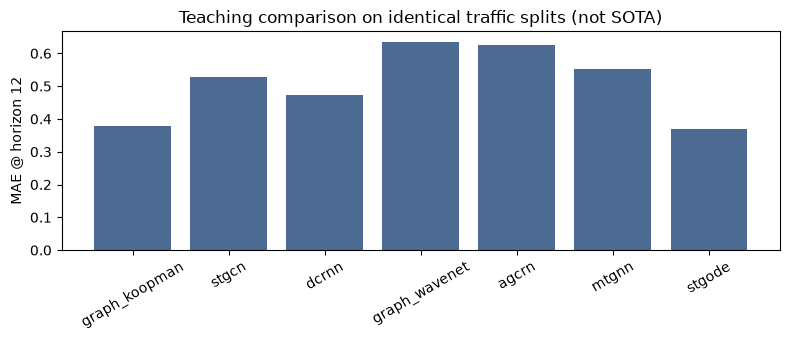


Data source: METR-LA tutorial cache (data/metr_la/traffic.pt); prefix sensors 0..23, T=96
Metric: MAE on test_seq; horizons=(3, 6, 12)

graph_koopman MAE: {3: 0.3558928072452545, 6: 0.35966619849205017, 12: 0.3775358200073242}
deviations:
  - linear latent Koopman operator with GNN encode/decode; not a LibCity traffic GNN
  - fit uses the library training loop (not next-frame MSE of the GNN teaching baselines)
stgcn MAE: {3: 0.34886422753334045, 6: 0.4545038044452667, 12: 0.5264254212379456}
deviations:
  - architecture: teaching-scale ST-Conv block count and channel widths; not Yu et al. METR-LA / PEMS-BAY capacity
  - architecture: no multi-horizon direct or scheduled decoding at the claimed evaluation horizon (next-frame fit only)
  - preprocessing: no LibCity / BasicTS Z-score or sensor normalization and no dataset-specific adjacency construction pipeline; callers supply GraphSnapshotSequence features and topology
  - splits: protocol reports train/val/test = 0.7/0.1/0.2 for teach

In [9]:
horizon_key = max(HORIZONS)
labels = [str(row["name"]) for row in traffic_rows]
values = [float(row["maes"][horizon_key]) for row in traffic_rows]  # type: ignore[index]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(labels, values, color="#4C6A92")
ax.set_ylabel(f"MAE @ horizon {horizon_key}")
ax.set_title("Teaching comparison on identical traffic splits (not SOTA)")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

print(f"\nData source: {DATA_SOURCE}")
print(f"Metric: MAE on test_seq; horizons={HORIZONS}\n")
for row in traffic_rows:
    print("=" * 72)
    print(row["name"], "MAE:", row["maes"])
    print("deviations:")
    for item in row["deviations"]:  # type: ignore[union-attr]
        print(f"  - {item}")

## Results — GraphCast mesh MAE (not traffic-comparable)

These MAE values use the synthetic lat–lon mesh from the deep-dive cell. They
are **not** on the same scale or graph class as the traffic table above; do not
merge them into a single ranking.

In [10]:
print("GraphCast teaching mesh — problem class: mesh-weather, not PEMS/METR")
print("mesh nodes/edges:", mesh_seq.num_nodes, mesh_seq.edge_index.shape[1])
print("MAE on mesh test (not comparable to traffic table):", gc_maes)
print("deviations:")
for item in gc_protocol.deviations:
    print(f"  - {item}")

GraphCast teaching mesh — problem class: mesh-weather, not PEMS/METR
mesh nodes/edges: 12 40
MAE on mesh test (not comparable to traffic table): {3: 0.030604759231209755, 6: 0.07148821155230205, 12: 0.2099840392669042}
deviations:
  - architecture: pure-PyTorch teaching encoder–processor–decoder on a tiny lat–lon mesh; not DeepMind JAX GraphCast or pretrained weights
  - data: no ERA5 / HRES / eccodes / multi-mesh hierarchy or pressure-level atmospheric state vector
  - problem class: mesh-weather teaching slice — not a PEMS/METR sensor-traffic forecaster; do not compare as traffic SOTA
  - architecture: next-frame fit only; not 10-day autoregressive weather rollouts at operational resolution
  - dependency: [baselines-graphcast] is reserved for future mesh helpers; teaching path needs only the core install
  - preprocessing: no LibCity / BasicTS Z-score or sensor normalization and no dataset-specific adjacency construction pipeline; callers supply GraphSnapshotSequence features and to

## Interpretation

On this short teaching slice, absolute MAE ranks are unstable across horizons
and random seeds and should not be extrapolated to full METR-LA or LibCity
scripts. What *is* stable is the protocol surface: identical splits and horizons
for the traffic models, explicit deviation tables, and a hard separation between
sensor-traffic and mesh-weather adapters. Use the Koopman model when you want a
linear latent operator under the same `evaluate_forecast` harness as the teaching
GNNs; use a teaching GNN when you need a nonlinear spatiotemporal reference on
the same splits — still without claiming METR-LA leaderboard status.

## Takeaways

- Use one documented prefix sensor slice and identical chronological splits
  (`0.7` / `0.1` / `0.2`) when comparing teaching forecasters.
- Read `protocol().deviations` next to every score; next-frame MSE training is
  not a paper multi-horizon LibCity recipe.
- GraphCast teaching lives on a lat–lon mesh and must not enter the traffic MAE
  table.
- These notebooks are for method comparison hygiene, not METR-LA leaderboard
  claims.
- Stored outputs are from the full local path (`IS_TEST=False`); CI/`nbmake`
  uses a shorter `IS_TEST` path with different $N$, $T$, and epochs.

## Further reading

- Yu, B., Yin, H., & Zhu, Z. (2018). Spatio-temporal graph convolutional
  networks. *IJCAI*.
- Li, Y., Yu, R., Shahabi, C., & Liu, Y. (2018). Diffusion convolutional
  recurrent neural network. *ICLR*.
- Wu, Z., Pan, S., Long, G., Jiang, J., & Zhang, C. (2019). Graph WaveNet for
  deep spatial-temporal graph modeling. *IJCAI*.
- Bai, L., Yao, L., Li, C., Wang, X., & Wang, C. (2020). Adaptive graph
  convolutional recurrent network for traffic forecasting. *NeurIPS*.
- Wu, Z., Pan, S., Long, G., Jiang, J., Chang, X., & Zhang, C. (2020).
  Connecting the dots: Multivariate time series forecasting with graph neural
  networks. *KDD*.
- Fang, Z., Long, Q., Song, G., & Xie, K. (2021). Spatial-temporal graph ODE
  networks for traffic flow forecasting. *KDD*.
- Lam, R., et al. (2023). Learning skillful medium-range global weather
  forecasting. *Science*.
- API: [`evaluate_forecast`](https://koopmangraph.readthedocs.io/en/latest/api.html)
  (metrics), teaching baselines and
  [`ForecasterProtocol`](https://koopmangraph.readthedocs.io/en/latest/api.html)
  under `koopman_graph.baselines.gnn`, and
  [`MetrLaTrafficBenchmark`](https://koopmangraph.readthedocs.io/en/latest/api.html)
  / [dataset card](https://koopmangraph.readthedocs.io/en/latest/data.html).
- In-repo peer: [`03_traffic_network.ipynb`](03_traffic_network.ipynb) (METR-LA
  Koopman walkthrough).